<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-05

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| transformers | 5.15.0 |

</details>

# Base-10 Arithmetic Behind Cyclic Reasoning

## Introduction

🧮 Ask Llama-3.1-8B *"what is six months after August?"* and it answers **February**. There are
two very different ways it could be doing that.

The intuitive story is **modular arithmetic on a circle**: months live on a 12-cycle, so the
model rotates around that circle by six and reads off where it lands. Under this story the
weekday task would use a 7-cycle, the hours task a 24-cycle — each concept with its own
geometry.

The paper's answer is the other one. The model converts the month to a **number**, does ordinary
**base-10 addition**, and converts back: `August(7) + 6 = 13 → 13 mod 12 → February`. The
arithmetic is task-agnostic, and its signature is that the numeric features have periods that
respect base 10 — **2, 5, and 10** — rather than the period of whatever cycle the task is about.

That gives a sharp, falsifiable prediction, which is what this notebook tests:

> In the weekday task, the period-**7** feature should be **absent**, while period 2, 5 and 10
> features are present — even though 7 is the only period the task itself cares about.

📗 [*Arithmetic in the Wild: Llama uses Base-10 Addition to Reason About Cyclic Concepts*](https://arxiv.org/abs/2605.01148)
(Feucht, Haklay, Bhalla, Wurgaft, Rager, Sarfati, Merullo, McGrath, Lewis, Lubana, Fel, Geiger),
written up as [*A Geometric Calculator Inside a Neural Network*](https://www.goodfire.ai/research/a-geometric-calculator).

The setup below follows the paper's where it can: accuracy is measured on **in-cycle offsets**,
the addition task runs over their range ($a, b \in \{1..100\}$), and the causal intervention uses
their steering equation and their way of scoring it. The paper's neuron-level account — a subspace
found with Distributed Alignment Search, and the ~28 layer-18 MLP neurons selected from it — needs
machinery well beyond a probe and is not attempted here.

## Setup

If using Colab, install NNsight:
```
!pip install -U nnsight
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight

In [2]:
import torch
import nnsight
from nnsight import TransformersModel

import numpy as np
import matplotlib.pyplot as plt

`meta-llama/Llama-3.1-8B` is a gated repository — accept the license and log in with
`huggingface-cli login` before running this.

In [3]:
model = TransformersModel(
    "meta-llama/Llama-3.1-8B", dtype=torch.bfloat16, device_map="auto", dispatch=True
)

LAYER = 18            # the layer the paper localises the addition to
layers = model.model.layers
print(f"{len(layers)} layers, reading layer {LAYER} at the last token")

32 layers, reading layer 18 at the last token


## The three tasks

Months, weekdays, and plain addition. Each prompt is two-shot and arranged so the **answer is
the very next token** — that way "the last token position" is unambiguously where the answer is
about to be produced.

In [4]:
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
WORDS = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
         "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen", "sixteen",
         "seventeen", "eighteen", "nineteen", "twenty", "twenty-one", "twenty-two",
         "twenty-three"]

def month_prompt(month, offset):
    return ("Q: What is three months after January?\nA: April\n"
            "Q: What is five months after October?\nA: March\n"
            f"Q: What is {WORDS[offset]} months after {MONTHS[month]}?\nA:")

def day_prompt(day, offset):
    return ("Q: What is three days after Monday?\nA: Thursday\n"
            "Q: What is five days after Saturday?\nA: Thursday\n"
            f"Q: What is {WORDS[offset]} days after {DAYS[day]}?\nA:")

def addition_prompt(a, b):
    return f"12+15=27\n43+21=64\n{a}+{b}="

print(month_prompt(7, 6))

Q: What is three months after January?
A: April
Q: What is five months after October?
A: March
Q: What is six months after August?
A:


In every case there is an **intermediate integer** $n$ — the sum before any wrapping. For
months, `August(7) + 6 = 13`; the answer is `MONTHS[13 % 12]`. That $n$ is what the paper claims
the model actually computes, and it is what we will probe for.

In [5]:
def next_token(prompts, batch_size=24):
    """Greedy next token for a list of prompts, batched into as few passes as possible."""
    decoded = []
    for start in range(0, len(prompts), batch_size):
        with model.trace() as tracer:
            picks = nnsight.save([])
            for prompt in prompts[start:start + batch_size]:
                with tracer.invoke(prompt):
                    picks.append(model.output.logits[0, -1].argmax())
        decoded += [model.tokenizer.decode([p.item()]).strip() for p in picks]
    return decoded

month_cases = [(m, o) for m in range(12) for o in range(1, 24)]
day_cases = [(d, o) for d in range(7) for o in range(1, 24)]
rng = np.random.default_rng(0)
addition_cases = [(a, b) for a in range(1, 35) for b in range(1, 35) if 2 <= a + b <= 34]
addition_cases = [addition_cases[i] for i in rng.permutation(len(addition_cases))[:600]]

month_preds = next_token([month_prompt(*c) for c in month_cases])
day_preds = next_token([day_prompt(*c) for c in day_cases])
addition_preds = next_token([addition_prompt(*c) for c in addition_cases])

# The paper quotes accuracy on *in-cycle* offsets (offset < cycle length); the wider range is kept
# for the probing data below, where more values of n is simply more signal.
in_cycle_months = [i for i, (_, o) in enumerate(month_cases) if o < 12]
in_cycle_days = [i for i, (_, o) in enumerate(day_cases) if o < 7]

month_acc = np.mean([month_preds[i] == MONTHS[sum(month_cases[i]) % 12] for i in in_cycle_months])
day_acc = np.mean([day_preds[i] == DAYS[sum(day_cases[i]) % 7] for i in in_cycle_days])
add_acc = np.mean([p == str(a + b) for p, (a, b) in zip(addition_preds, addition_cases)])

print(f"months   : {month_acc:.3f}   (paper: 0.82)")
print(f"weekdays : {day_acc:.3f}   (paper: 0.92)")
print(f"addition : {add_acc:.3f}")
print(f"\nthe paper's example — six months after August: {next_token([month_prompt(7, 6)])[0]!r}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


months   : 0.985   (paper: 0.82)
weekdays : 0.929   (paper: 0.92)
addition : 1.000

the paper's example — six months after August: 'February'


Close to the paper on both cyclic tasks, and the worked example comes out exactly right. (Push the
offsets past one full cycle and weekday accuracy collapses — to about 0.5 out to offset 23 — which
is why the in-cycle restriction is the number worth quoting.)

## Reading layer 18

One trace per prompt, one saved vector each: the residual stream after block 18 at the final
position.

In [6]:
def collect(prompts, batch_size=24):
    activations = []
    for start in range(0, len(prompts), batch_size):
        with model.trace() as tracer:
            batch = nnsight.save([])
            for prompt in prompts[start:start + batch_size]:
                with tracer.invoke(prompt):
                    batch.append(layers[LAYER].output[0, -1].detach().float().cpu())
        activations += list(batch)
    return torch.stack(activations).numpy().astype(np.float64)

X_month = collect([month_prompt(*c) for c in month_cases])
X_day = collect([day_prompt(*c) for c in day_cases])
X_add = collect([addition_prompt(*c) for c in addition_cases])

n_month = np.array([m + o for m, o in month_cases])      # the pre-wrap sum
n_day = np.array([d + o for d, o in day_cases])
n_add = np.array([a + b for a, b in addition_cases])

TASKS = {"addition": (X_add, n_add), "months": (X_month, n_month), "weekdays": (X_day, n_day)}
for name, (X, _) in TASKS.items():
    print(f"{name:9s} {X.shape}")

addition  (561, 4096)
months    (276, 4096)
weekdays  (161, 4096)


## A control first

Before reading anything into a period sweep, one thing has to be established, because it
changes how the whole table should be read: **is $n$ itself linearly decodable?**

The probe is ridge regression, written out rather than pulled from a library. Because there are
far more dimensions (4096) than examples, the cheap way is the **dual form**: work with the
$n \times n$ kernel $X X^{\top}$ instead of the $d \times d$ covariance. One eigendecomposition
per fold then serves every regularization strength *and* every target, so the whole period sweep
below costs one setup and nothing after it.

In [7]:
ALPHAS = np.logspace(1, 6, 12)

class Probe:
    """Cross-validated ridge regression from a fixed X to any target.

    The expensive part depends only on X, so it is computed once at construction. `r2` reports
    the best out-of-fold R² over the ridge grid — the same selection for every period, which is
    what makes the periods comparable to each other.
    """

    def __init__(self, X, folds=5, seed=0):
        self.n = len(X)
        order = np.random.default_rng(seed).permutation(len(X))
        parts = np.array_split(order, folds)
        self.folds = []
        for f in range(folds):
            test = parts[f]
            train = np.concatenate([parts[g] for g in range(folds) if g != f])
            centre = X[train].mean(0)
            centred = X[train] - centre
            eigenvalues, eigenvectors = np.linalg.eigh(centred @ centred.T)
            self.folds.append((train, test, eigenvectors, eigenvalues,
                               (X[test] - centre) @ centred.T))

    def r2(self, target):
        target = np.asarray(target, dtype=float).reshape(self.n, -1)
        predictions = {a: np.zeros_like(target) for a in ALPHAS}
        for train, test, V, s, K_test in self.folds:
            mean = target[train].mean(0)
            projected = V.T @ (target[train] - mean)
            for a in ALPHAS:
                predictions[a][test] = K_test @ (V @ (projected / (s + a)[:, None])) + mean
        total = ((target - target.mean(0)) ** 2).sum(0)
        return max(float(np.mean(1 - ((target - p) ** 2).sum(0) / total))
                   for p in predictions.values())

probes = {name: Probe(X) for name, (X, _) in TASKS.items()}

for name, (X, n) in TASKS.items():
    print(f"  R²(n) from layer {LAYER}, {name:9s}: {probes[name].r2(n):.3f}")

  R²(n) from layer 18, addition : 0.994
  R²(n) from layer 18, months   : 0.996
  R²(n) from layer 18, weekdays : 0.996


It is, almost perfectly. That has a consequence worth stating before the results rather than
after: **if $n$ is decodable, so is any smooth function of $n$.** Over our range of $n$ (2–34),
$\sin(2\pi n / T)$ for a large $T$ is nearly a straight line in $n$, so long periods will score
well for free and mean nothing.

Short periods are the informative ones, because $\sin(2\pi n/3)$ oscillates several times across
the range and cannot be faked by a linear read-out of $n$. That is where the base-10 prediction
lives, and it is why the sweep below is only interpretable at the left-hand end.

## The period sweep

For each period $T$, fit a linear probe from the layer-18 activation to
$(\sin(2\pi n/T), \cos(2\pi n/T))$ and score it out-of-fold. At $T=2$ the sine is identically
zero, so only the cosine (the parity of $n$) is used.

In [8]:
def phase_targets(n, T):
    """(sin, cos) of n at period T. At T=2 the sine is identically zero, so only parity remains."""
    return np.stack([c for c in (np.sin(2 * np.pi * n / T), np.cos(2 * np.pi * n / T))
                     if c.std() > 1e-6], 1)

periods = list(range(2, 25))
sweep = {name: [probes[name].r2(phase_targets(n, T)) for T in periods]
         for name, (X, n) in TASKS.items()}

print(f"{'T':>4}" + "".join(f"{k:>11}" for k in TASKS) + "   ")
for i, T in enumerate(periods):
    note = {2: "base-10", 5: "base-10", 10: "base-10",
            7: "<- WEEKDAY CYCLE", 12: "<- MONTH CYCLE"}.get(T, "")
    print(f"{T:>4}" + "".join(f"{sweep[k][i]:>11.3f}" for k in TASKS) + f"   {note}")

   T   addition     months   weekdays   
   2      0.986      0.938      0.868   base-10
   3      0.016     -0.007     -0.020   
   4     -0.002     -0.010     -0.010   
   5      0.957      0.842      0.804   base-10
   6      0.006     -0.019     -0.007   
   7      0.004     -0.007     -0.006   <- WEEKDAY CYCLE
   8      0.145      0.073      0.143   
   9      0.715      0.651      0.718   
  10      0.948      0.905      0.871   base-10
  11      0.831      0.800      0.715   
  12      0.656      0.606      0.524   <- MONTH CYCLE
  13      0.554      0.476      0.408   
  14      0.532      0.435      0.370   
  15      0.560      0.454      0.386   
  16      0.602      0.506      0.432   
  17      0.659      0.566      0.489   
  18      0.706      0.627      0.548   
  19      0.747      0.683      0.602   
  20      0.792      0.728      0.651   
  21      0.822      0.766      0.694   
  22      0.847      0.796      0.732   
  23      0.872      0.820      0.764   
  24  

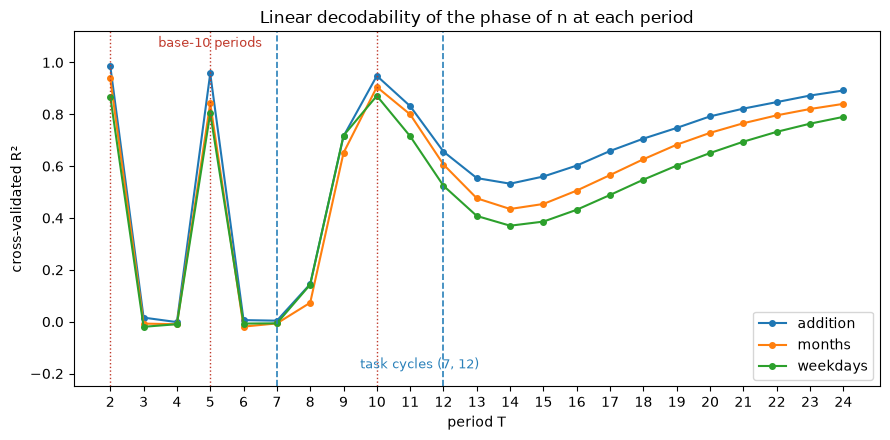

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, values in sweep.items():
    ax.plot(periods, values, marker="o", markersize=4, label=name)
for T, colour in [(2, "#c0392b"), (5, "#c0392b"), (10, "#c0392b")]:
    ax.axvline(T, color=colour, ls=":", lw=1)
ax.axvline(7, color="#2980b9", ls="--", lw=1.2)
ax.axvline(12, color="#2980b9", ls="--", lw=1.2)
ax.text(5, 1.06, "base-10 periods", color="#c0392b", ha="center", fontsize=9)
ax.text(9.5, -0.18, "task cycles (7, 12)", color="#2980b9", fontsize=9)
ax.set(xlabel="period T", ylabel="cross-validated R²",
       title="Linear decodability of the phase of n at each period",
       ylim=(-0.25, 1.12), xticks=periods)
ax.legend()
plt.tight_layout()
plt.show()

This is the result.

**Sharp peaks at 2, 5 and 10** — the base-10 periods — in all three tasks, at R² between 0.80
and 0.99. **Troughs at 3, 4, 6 and 7**, all essentially zero. The features are not "any period
works because $n$ is decodable"; specific short periods are present and their neighbours are
not, and the ones present are exactly the divisors of 10.

And the prediction the whole thing turns on:

- **Period 7 in the weekday task: -0.006.** The task is entirely about a 7-cycle. If the model
  rotated around a weekday circle, this is the one feature that would have to exist. It is not
  there - while periods 2, 5 and 10 in those *same* activations score 0.87, 0.80 and 0.87. The
  weekday representation carries a base-10 running sum even on a task the model gets right only
  half the time; what it never carries is a seven.
- **Period 12 in the months task: not a peak.** It scores 0.61 - *below* its neighbour at 11
  (0.80), sitting on the smooth long-period slope the control section predicted. Compare a real
  feature: period 10 scores 0.91 against 0.07 at 8. Period 12 is unremarkable against its
  surroundings; 2, 5 and 10 are spikes.

So the weekday task is not done in mod-7 and the month task is not done in mod-12. Both are done
in base 10, with the wrap applied afterwards — which is the paper's claim.

### Is it the sum, or just the operands?

One objection has to be dealt with before any of this means what it looks like. The offset
("six") and the month ("August") are *both sitting in the prompt*. If the model simply encodes
those two numbers with base-10 Fourier features, a probe might be reading them rather than
anything it computed.

In [10]:
month_index = np.array([m for m, _ in month_cases])
offsets = np.array([o for _, o in month_cases])

print(f"{'T':>4}{'sum n':>9}{'offset':>9}{'month':>8}{'answer n%12':>13}")
for T in (5, 10):
    print(f"{T:>4}{probes['months'].r2(phase_targets(n_month, T)):>9.3f}"
          f"{probes['months'].r2(phase_targets(offsets, T)):>9.3f}"
          f"{probes['months'].r2(phase_targets(month_index, T)):>8.3f}"
          f"{probes['months'].r2(phase_targets(n_month % 12, T)):>13.3f}")

   T    sum n   offset   month  answer n%12
   5    0.842    0.981   0.983       -0.009
  10    0.905    0.986   0.992        0.484


The objection has teeth: the operands are base-10 encoded too, and *more* strongly than the sum
(0.98 against 0.84). So the representation carries Fourier features of numbers generally, not
only of the answer.

But it does not explain the result away, for a reason worth spelling out:

$$\sin\!\left(\tfrac{2\pi(m+o)}{5}\right) = \sin\tfrac{2\pi m}{5}\cos\tfrac{2\pi o}{5} + \cos\tfrac{2\pi m}{5}\sin\tfrac{2\pi o}{5}$$

The sum's phase is a **product** of the operands' phases, not a linear combination of them. A
linear probe cannot build it out of separately-encoded operand features — the products have to
already be there. That the sum's phase is linearly decodable at all is the evidence that
something computed it.

A stricter version of the same check: hold out *entire offsets*, so the probe is tested on
offsets it never saw during fitting.

In [11]:
class GroupedProbe(Probe):
    """Probe whose folds hold out whole groups (e.g. every row with a given offset)."""

    def __init__(self, X, groups, folds=5, seed=0):
        self.n = len(X)
        unique = np.unique(groups)
        chunks = np.array_split(np.random.default_rng(seed).permutation(unique), folds)
        self.folds = []
        for chunk in chunks:
            test = np.where(np.isin(groups, chunk))[0]
            train = np.where(~np.isin(groups, chunk))[0]
            centre = X[train].mean(0)
            centred = X[train] - centre
            eigenvalues, eigenvectors = np.linalg.eigh(centred @ centred.T)
            self.folds.append((train, test, eigenvectors, eigenvalues,
                               (X[test] - centre) @ centred.T))

held_out = GroupedProbe(X_month, offsets)
print("offsets held out entirely from fitting:")
print(f"{'T':>4}{'sum n':>9}{'offset':>9}")
for T in (5, 10, 3, 7):
    print(f"{T:>4}{held_out.r2(phase_targets(n_month, T)):>9.3f}"
          f"{held_out.r2(phase_targets(offsets, T)):>9.3f}")

offsets held out entirely from fitting:
   T    sum n   offset
   5    0.835    0.781
  10    0.905    0.855
   3   -0.000   -0.056
   7   -0.004   -0.154


The sum's phase still decodes at 0.84 (period 5) and 0.91 (period 10) on offsets the probe never
saw, and periods 3 and 7 stay at zero. The base-10 structure is not an artefact of memorising
which offsets appeared with which months.

## The paper's full period list

The sweep above stops at 24 because the months and weekday sums are small. The paper works over
$a, b \in \{1..100\}$ — sums up to 200 — and sweeps $1 \le T \le 150$, reporting that periods
$T \in \{2, 5, 10, 20, 50, 100\}$ are recoverable. Long periods only become testable on that
range: over sums of at most 34, $\sin(2\pi n/50)$ is barely distinguishable from a straight line.

In [12]:
rng_big = np.random.default_rng(0)
big_pairs = [(a, b) for a in range(1, 101) for b in range(1, 101)]
big_pairs = [big_pairs[i] for i in rng_big.permutation(len(big_pairs))[:900]]

X_big = collect([addition_prompt(*c) for c in big_pairs])
n_big = np.array([a + b for a, b in big_pairs])
probe_big = Probe(X_big)

print(f"sums span {n_big.min()}..{n_big.max()}\n")
print(f"{'T':>5}{'R²':>9}   ")
for T in [2, 3, 5, 7, 10, 20, 50, 100, 150]:
    listed = "  <- listed in the paper" if T in (2, 5, 10, 20, 50, 100) else ""
    print(f"{T:>5}{probe_big.r2(phase_targets(n_big, T)):>9.3f}{listed}")

sums span 3..198

    T       R²   
    2    0.982  <- listed in the paper
    3    0.076
    5    0.962  <- listed in the paper
    7   -0.001
   10    0.943  <- listed in the paper
   20    0.426  <- listed in the paper
   50    0.956  <- listed in the paper
  100    0.970  <- listed in the paper
  150    0.967


Five of their six come out strongly (2, 5, 10, 50, 100 all above 0.94). **Period 20 is the one
that doesn't** — 0.43 here against their report that it is reliably recoverable. That is the
single number in this notebook that sits meaningfully below the paper, and with a plain ridge
probe rather than their trained affine probes it is hard to say whether the difference is the
model or the method.

## Steering the features

Now the causal question. The paper's intervention (their Eq. 4) writes a target phase into the
activation along the **unit-normalised** probe directions, scaled by the component's own radius
in that forward pass:

$$\mathbf{h} \leftarrow \mathbf{h} + \big(\alpha\, r_T \sin(\theta_T n') - \hat{s}\big)\,\hat{\mathbf{w}}_{\sin} + \big(\alpha\, r_T \cos(\theta_T n') - \hat{c}\big)\,\hat{\mathbf{w}}_{\cos}$$

where $\hat{s}, \hat{c}$ are the current read-outs, $r_T = \sqrt{\hat{s}^2 + \hat{c}^2}$, and
$\alpha = 10$. The large $\alpha$ is theirs, and they are explicit about what it implies: *"the
need for this high α suggests that these features alone may not fully override downstream
computation."*

How it is scored matters just as much. The paper does not report a hit rate — it steers every
prompt toward each target in turn and looks at the **output distribution**, expecting probability
mass to concentrate on the intended month. A strong diagonal is the result. Scoring top-1 instead
is a much harsher test than the claim being made.

In [13]:
STEER_PERIODS = [2, 5, 10, 20]
ALPHA = 10.0

def ridge_fit(X, Y, alpha=1e3):
    """Ridge weights in dual form (n << d): W = Xᶜᵀ (Xᶜ Xᶜᵀ + αI)⁻¹ Yᶜ."""
    centre, offset = X.mean(0), Y.mean(0)
    Xc = X - centre
    W = Xc.T @ np.linalg.solve(Xc @ Xc.T + alpha * np.eye(len(X)), Y - offset)
    return W, centre, offset

month_tokens = [model.tokenizer.encode(" " + name, add_special_tokens=False)[0]
                for name in MONTHS]

def unit_directions(X, n, periods):
    """Unit-normalised sin/cos read-out directions per period, plus the centring vector.

    At T=2 the sine is identically zero, so that period contributes a cosine (parity) term only.
    """
    centre = X.mean(0)
    unit = lambda v: v / np.linalg.norm(v)
    directions = {}
    for T in periods:
        targets = phase_targets(n, T)                  # 2 columns, or 1 when T=2
        W, _, _ = ridge_fit(X, targets)
        if targets.shape[1] == 2:
            directions[T] = (unit(W[:, 0]), unit(W[:, 1]))
        else:
            directions[T] = (None, unit(W[:, 0]))      # cosine only
    return directions, centre

directions, centre = unit_directions(X_month, n_month, STEER_PERIODS)

def steer_to(prompt, n_target, alpha=ALPHA):
    """Write the phases of `n_target` into layer 18, return the month distribution."""
    with model.trace(prompt):
        hidden = layers[LAYER].output[0, -1].detach().float().cpu().save()
    hidden = hidden.numpy().astype(np.float64)

    delta = np.zeros_like(hidden)
    centred = hidden - centre
    for T, (w_sin, w_cos) in directions.items():
        theta = 2 * np.pi / T
        c_hat = centred @ w_cos
        s_hat = centred @ w_sin if w_sin is not None else 0.0
        radius = np.hypot(s_hat, c_hat)
        if w_sin is not None:
            delta += (alpha * radius * np.sin(theta * n_target) - s_hat) * w_sin
        delta += (alpha * radius * np.cos(theta * n_target) - c_hat) * w_cos

    edited = torch.tensor(hidden + delta, dtype=torch.bfloat16, device=model.device)
    with model.trace(prompt):
        layers[LAYER].output[0, -1] = edited
        logits = model.output.logits[0, -1].float().save()
    probabilities = torch.softmax(logits, -1)[month_tokens].detach().cpu().numpy()
    return probabilities / probabilities.sum()

steered_prompts = [month_prompt(m, o) for m, o in month_cases[::12]][:12]
diagonal = np.zeros((12, 12))
for target in range(12):
    diagonal[target] = np.mean([steer_to(p, target) for p in steered_prompts], axis=0)

print("row = month steered toward, column = month the model then predicts\n")
print("      " + "".join(f"{name[:3]:>5}" for name in MONTHS))
for i, row in enumerate(diagonal):
    hit = "  <-" if row.argmax() == i else ""
    print(f"{MONTHS[i][:3]:>5} " + "".join(f"{v:5.2f}" for v in row) + hit)

on_diag = np.diag(diagonal).mean()
off_diag = (diagonal.sum() - np.trace(diagonal)) / (144 - 12)
print(f"\nmean on-diagonal {on_diag:.3f}   mean off-diagonal {off_diag:.3f}   ratio {on_diag / off_diag:.1f}x")
print(f"intended month is the argmax in {sum(diagonal[i].argmax() == i for i in range(12))}/12 rows")

row = month steered toward, column = month the model then predicts

        Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
  Jan  0.11 0.06 0.17 0.08 0.25 0.05 0.03 0.02 0.06 0.04 0.07 0.06
  Feb  0.25 0.35 0.02 0.03 0.03 0.03 0.01 0.03 0.12 0.06 0.04 0.03  <-
  Mar  0.42 0.12 0.22 0.06 0.03 0.03 0.03 0.01 0.01 0.00 0.05 0.03
  Apr  0.07 0.10 0.12 0.60 0.01 0.01 0.00 0.06 0.00 0.01 0.01 0.02  <-
  May  0.11 0.08 0.17 0.39 0.18 0.01 0.00 0.01 0.01 0.01 0.00 0.02
  Jun  0.03 0.02 0.02 0.21 0.08 0.54 0.01 0.01 0.02 0.02 0.02 0.02  <-
  Jul  0.03 0.03 0.05 0.00 0.00 0.03 0.81 0.01 0.01 0.00 0.00 0.00  <-
  Aug  0.02 0.03 0.02 0.05 0.01 0.01 0.01 0.83 0.01 0.00 0.00 0.01  <-
  Sep  0.07 0.02 0.15 0.19 0.09 0.01 0.01 0.08 0.35 0.01 0.00 0.01  <-
  Oct  0.08 0.03 0.05 0.23 0.10 0.03 0.01 0.01 0.05 0.36 0.00 0.02  <-
  Nov  0.07 0.03 0.22 0.06 0.17 0.02 0.03 0.01 0.02 0.04 0.20 0.14
  Dec  0.15 0.44 0.02 0.01 0.01 0.02 0.01 0.01 0.04 0.03 0.02 0.24

mean on-diagonal 0.399   mean of

The diagonal is there — about 7x the off-diagonal mass, and the intended month is the single
most likely answer in 7 of the 12 rows. Writing a different sum into the period-2/5/10/20
features moves the model's answer toward the month that sum implies, on a prompt where nothing
else changed.

It is not clean, and the paper says as much: at $\alpha = 10$ the features are being driven well
past their natural magnitude, which is what you would expect if they are *part of* the causal
path rather than the whole of it.

### An aliasing artefact worth knowing about

Run this with `STEER_PERIODS = [2, 5, 10]` and two pairs of rows come out **identical** — January
with November, February with December. That is not a bug. Those periods only pin down
$n \bmod \operatorname{lcm}(2,5,10) = n \bmod 10$, so targets ten apart are the same instruction.
Adding period 20 separates them, and the diagonal improves.

It is a small, concrete demonstration of the residue-number-system picture the paper describes:
each period contributes one residue, and the range you can address is their least common multiple.

## Conclusion

🎉 Layer 18 of Llama-3.1-8B carries the phase of the running sum at base-10 periods — 2, 5, 10,
and on the paper's wider range 50 and 100 as well — and **not** at 3, 4, 6 or 7. That holds in a
task whose entire structure is a 7-cycle and in one built on a 12-cycle. Neither is being done in
its own modular arithmetic; both are done in base 10 and wrapped afterwards.

The features are also causally involved: writing a different sum into them shifts the model's
answer toward the month that sum implies, about an order of magnitude above baseline. Not
decisively — the paper's own α = 10 is a statement that these features are not the whole story.

Two things this notebook is deliberately careful about, because both nearly went wrong:

- **Control for the inputs.** The operands are base-10 encoded too, more strongly than the sum.
  The result survives only because the sum's phase is a *product* of the operands' phases, which
  a linear probe cannot manufacture.
- **Sweep before concluding.** A single (layer, strength) setting is not a result, and scoring an
  intervention by top-1 when the claim is about distribution shift will manufacture a negative.

What is not here: the paper's mechanistic core — a subspace located with Distributed Alignment
Search, and the ~28 layer-18 MLP neurons selected from it, whose ablation takes addition accuracy
from 95% to 24%. That needs DAS, which is a project rather than a notebook section.

Related: [Progress Measures for Grokking](grokking-progress-measures.ipynb) for Fourier features doing modular
arithmetic in a toy model trained from scratch,
[Logit Lens](../tutorials/probing/logit_lens.ipynb) for reading representations, and
[Gradients](../../features/3_gradients.ipynb) for the API heavier attribution methods build on.

## References

- Feucht, Haklay, Bhalla, Wurgaft, Rager, Sarfati, Merullo, McGrath, Lewis, Lubana, Fel, Geiger, [*Arithmetic in the Wild: Llama uses Base-10 Addition to Reason About Cyclic Concepts*](https://arxiv.org/abs/2605.01148), 2026
- Goodfire, [*A Geometric Calculator Inside a Neural Network*](https://www.goodfire.ai/research/a-geometric-calculator) — the accompanying write-up, with interactive demos
- Geiger et al., [*Finding Alignments Between Interpretable Causal Variables and Distributed Neural Representations*](https://arxiv.org/abs/2303.02536) — Distributed Alignment Search, the method behind the subspace this notebook could not shortcut
- Nanda et al., [*Progress measures for grokking via mechanistic interpretability*](https://arxiv.org/abs/2301.05217) — Fourier features for modular arithmetic in a toy model ([notebook](grokking-progress-measures.ipynb))